In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplot2tikz
import numpy as np

In [34]:
df = pd.read_csv('../log/new_20251204.csv', header = None, names = ['dataset', 'train_fitness', 'test_fitness',  'parameters',
                                                        'depth', 'width', 'test_brmse', 'test_mcc', 'test_bce','seed', 'generation', 'timing'])

In [35]:
baseline_nn = pd.read_csv('../log/baseline_dropout_20251209.csv', header = None, names = ['dataset', 'test_brmse', 'test_bce',  'test_mcc',
                                                                                          'seed', 'generation', 'timing'])

In [36]:
baseline_nn.head()

,dataset,test_brmse,test_bce,test_mcc,seed,generation,timing
0,brain_tumor_rn18_10,0.514239,0.722899,-0.0,7,1000,785.888560
1,brain_tumor_rn18_10,0.514021,0.722424,-0.0,11,1000,798.132150
2,brain_tumor_rn18_10,0.514080,0.722551,-0.0,24,1000,825.118341
3,brain_tumor_rn18_10,0.514569,0.723619,-0.0,28,1000,830.751636
4,brain_tumor_rn18_10,0.514086,0.722566,-0.0,12,1000,825.667900


In [37]:
df.head()

,dataset,train_fitness,test_fitness,parameters,depth,width,test_brmse,test_mcc,test_bce,seed,generation,timing
0,brain_tumor_rn18_10_brmse,0.414410,0.483796,6355,1,4,0.483796,-0.257960,0.660831,2,0,85.857780
1,brain_tumor_rn18_10_brmse,0.414410,0.483796,6355,1,4,0.483796,-0.257960,0.660831,2,1,0.262601
2,brain_tumor_rn18_10_brmse,0.414410,0.483796,6355,1,4,0.483796,-0.257960,0.660831,2,2,0.259686
3,brain_tumor_rn18_10_brmse,0.421357,0.492740,5774,1,3,0.492740,-0.146327,0.678406,1,0,86.375614
4,brain_tumor_rn18_50_brmse,0.402628,0.464487,2587,1,3,0.464487,-0.416462,0.622250,2,0,86.057930


In [38]:
df[df['generation'] == 1000][['dataset', 'depth', 'width' ]].groupby('dataset').median().to_dict()

{'depth': {'brain_tumor_rn18_100_bce': 479.0,
  'brain_tumor_rn18_100_brmse': 489.0,
  'brain_tumor_rn18_100_mcc': 20.0,
  'brain_tumor_rn18_10_bce': 477.0,
  'brain_tumor_rn18_10_brmse': 473.0,
  'brain_tumor_rn18_10_mcc': 3.0,
  'brain_tumor_rn18_250_bce': 477.0,
  'brain_tumor_rn18_250_brmse': 475.0,
  'brain_tumor_rn18_250_mcc': 128.0,
  'brain_tumor_rn18_500_bce': 486.0,
  'brain_tumor_rn18_500_brmse': 490.0,
  'brain_tumor_rn18_500_mcc': 174.0,
  'brain_tumor_rn18_50_bce': 476.0,
  'brain_tumor_rn18_50_brmse': 476.0,
  'brain_tumor_rn18_50_mcc': 69.0,
  'brain_tumor_rn34_100_bce': 457.0,
  'brain_tumor_rn34_100_brmse': 465.0,
  'brain_tumor_rn34_100_mcc': 15.0,
  'brain_tumor_rn34_10_bce': 479.0,
  'brain_tumor_rn34_10_brmse': 466.0,
  'brain_tumor_rn34_10_mcc': 2.0,
  'brain_tumor_rn34_250_bce': 481.0,
  'brain_tumor_rn34_250_brmse': 477.0,
  'brain_tumor_rn34_250_mcc': 68.0,
  'brain_tumor_rn34_500_bce': 480.0,
  'brain_tumor_rn34_500_brmse': 481.0,
  'brain_tumor_rn34_500_mcc'

In [39]:
df['test_mcc'] = df.test_mcc.apply(lambda x: -1.0*x)

In [40]:
df['train_fitness'] = df.train_fitness.apply(lambda x: -1.0*x if x < 0 else x)
df['test_fitness'] = df.test_fitness.apply(lambda x: -1.0*x if x < 0 else x)

In [41]:
df['train_size'] = df.dataset.apply(lambda x: x.split('_')[-2])
df['train_metric'] = df.dataset.apply(lambda x: x.split('_')[-1])
df['encoding'] = df.dataset.apply(lambda x: x.split('_')[-3])
df['dataset'] = df.dataset.apply(lambda x: '_'.join(x.split('_')[:-3]))

In [42]:
df['train_size']  =df['train_size'].astype(int)

In [43]:
baseline_nn['train_size'] = baseline_nn.dataset.apply(lambda x: x.split('_')[-1])
baseline_nn['encoding'] = baseline_nn.dataset.apply(lambda x: x.split('_')[-2])
baseline_nn['dataset'] = baseline_nn.dataset.apply(lambda x: '_'.join(x.split('_')[:-2]))

In [44]:
baseline_nn['train_size']  = baseline_nn['train_size'].astype(int)

In [45]:
# Group by dataset, train_size, encoding, train_metric
grouped = df.groupby(['dataset', 'train_size', 'encoding', 'train_metric'])[['test_brmse', 'test_mcc', 'test_bce']].mean()

In [46]:
grouped

test_brmse  test_mcc  test_bce
dataset      train_size encoding train_metric                                
brain_tumor  10         rn18     bce             0.492677  0.173578  0.678641
                                 brmse           0.492505  0.176511  0.678312
                                 mcc             0.495604  0.117380  0.684332
                        rn34     bce             0.492640  0.212416  0.678920
                                 brmse           0.492618  0.216847  0.678851
...                                                   ...       ...       ...
tuberculosis 500        rn34     brmse           0.440378  0.443864  0.572930
                                 mcc             0.453791  0.411133  0.599673
                        rn50     bce             0.435588  0.485682  0.564409
                                 brmse           0.436506  0.503559  0.566464
                                 mcc             0.453344  0.444350  0.599128

[90 rows x 3 columns]

In [47]:
# Get unique combinations
datasets = df['dataset'].unique()
train_sizes = df['train_size'].unique()
encodings = df['encoding'].unique()

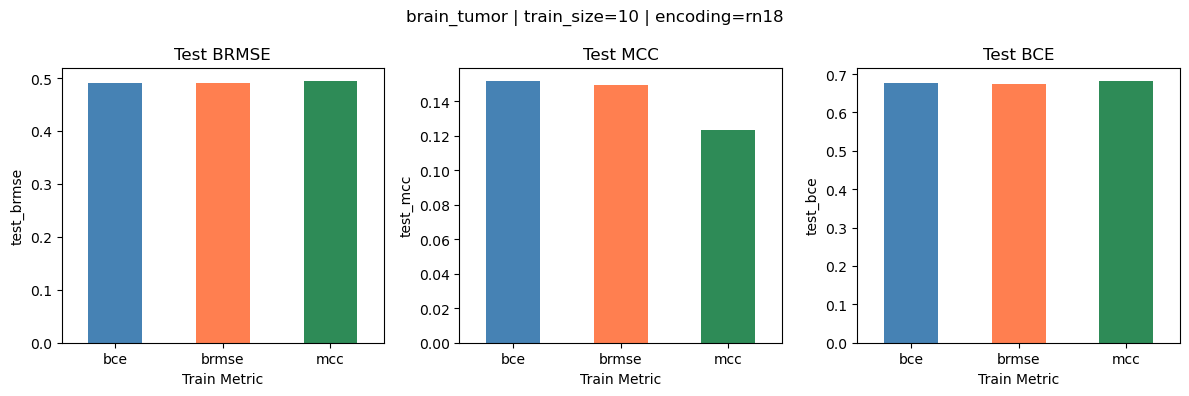

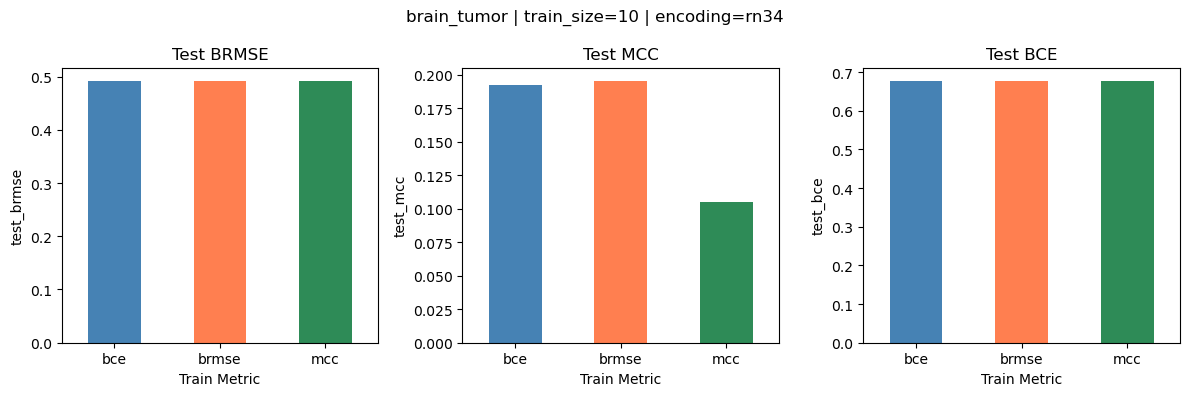

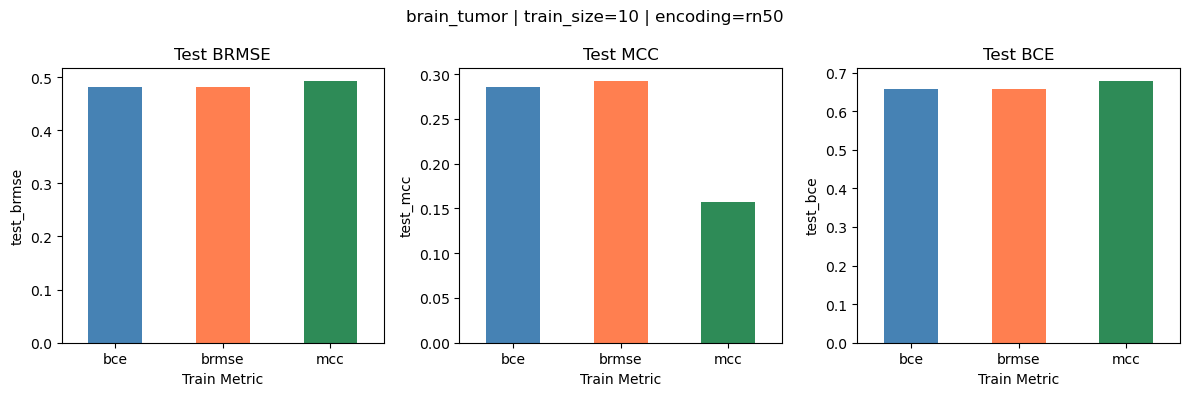

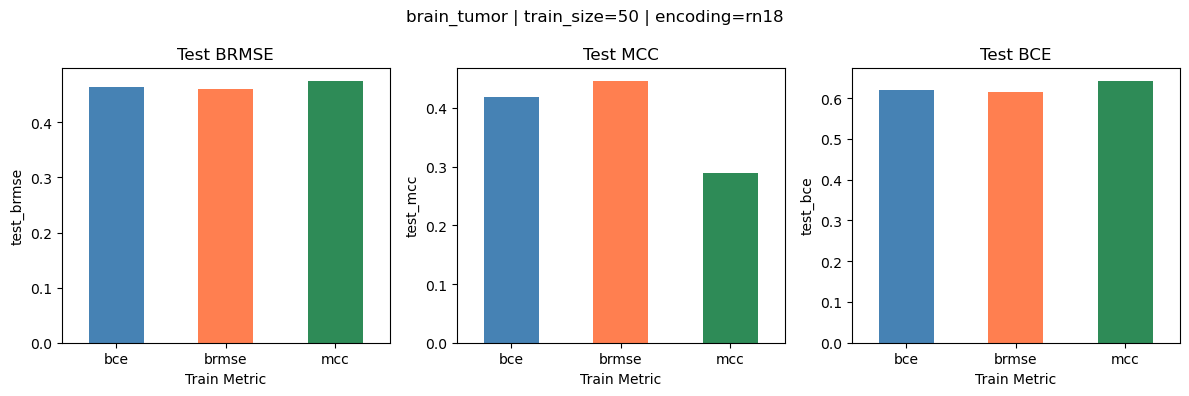

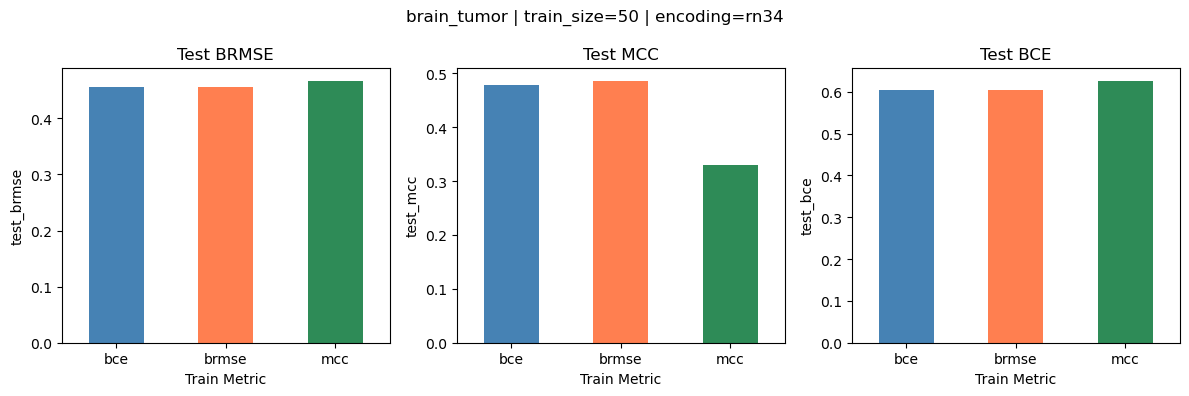

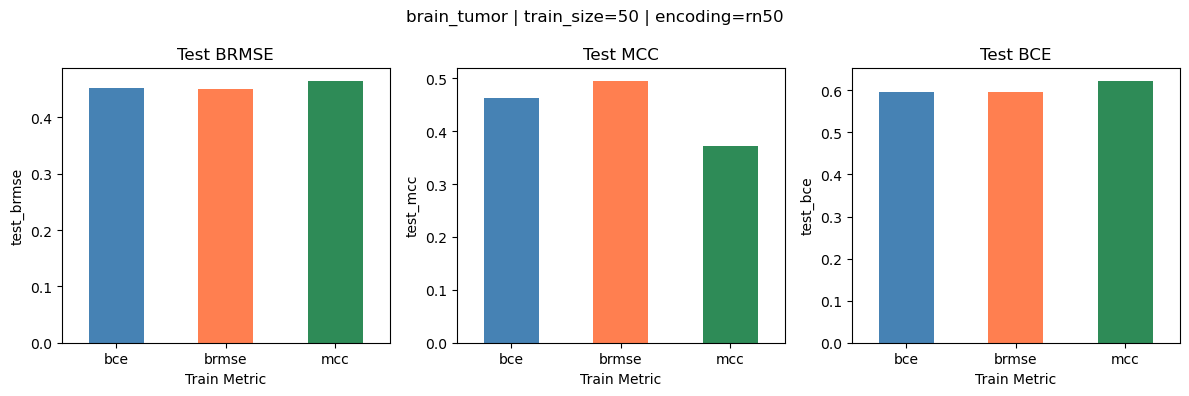

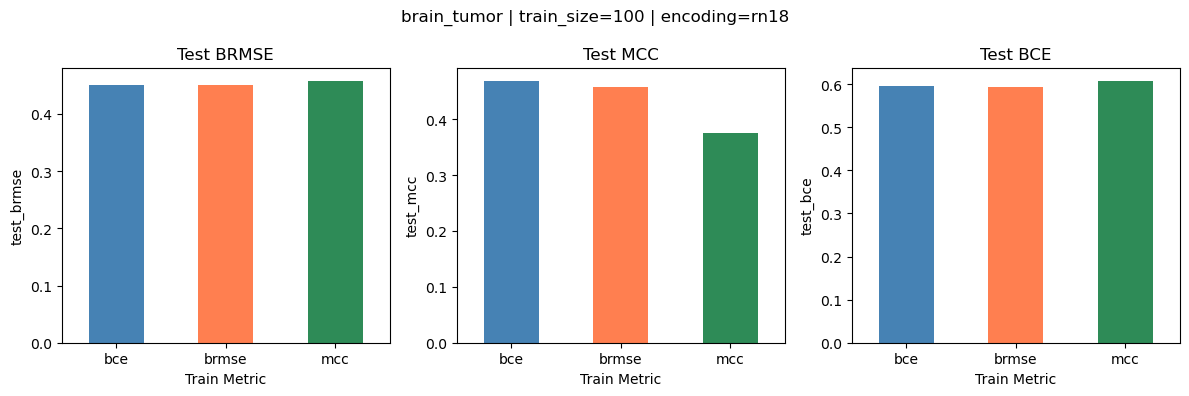

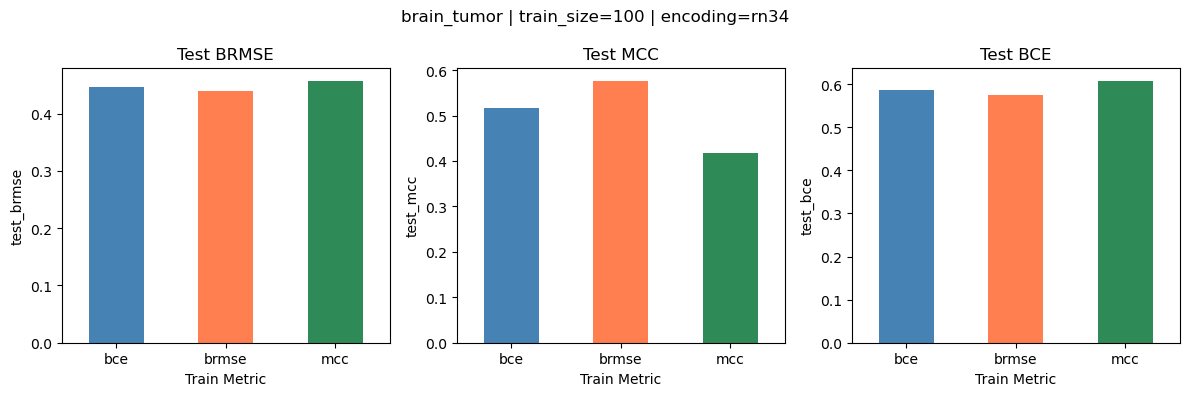

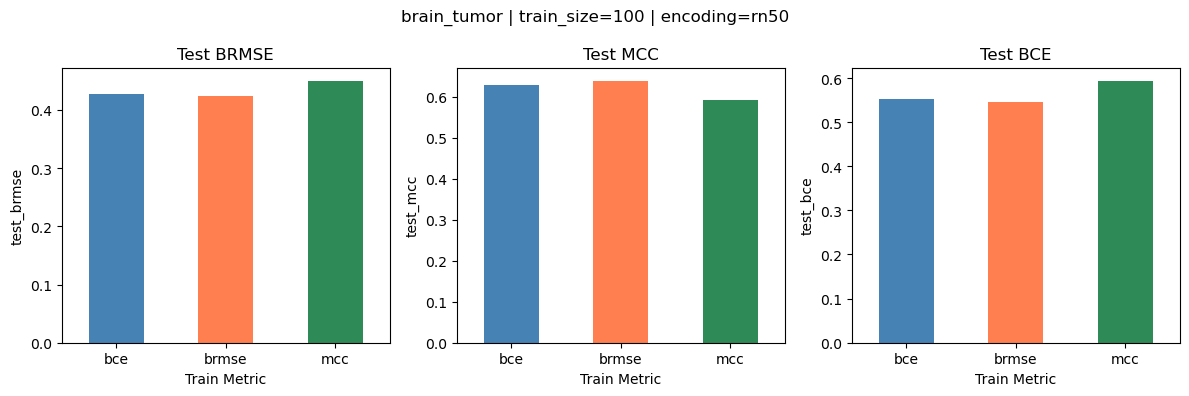

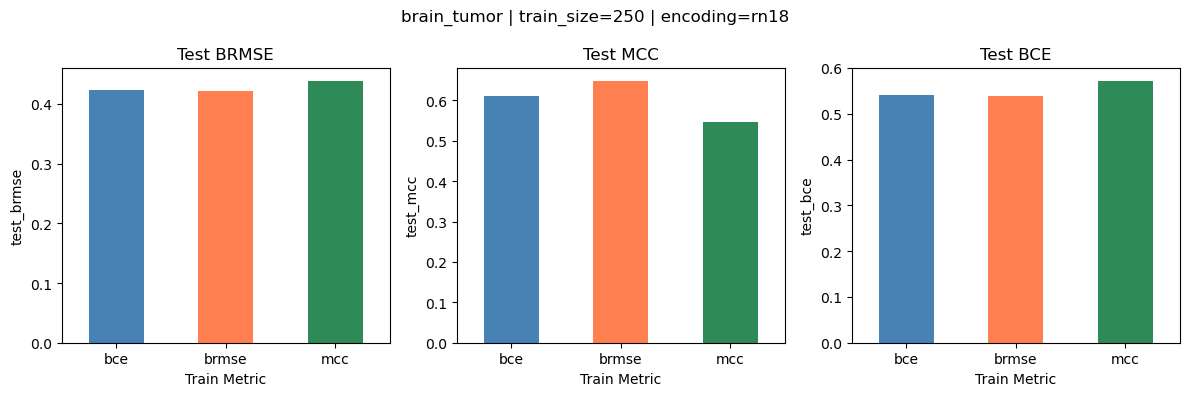

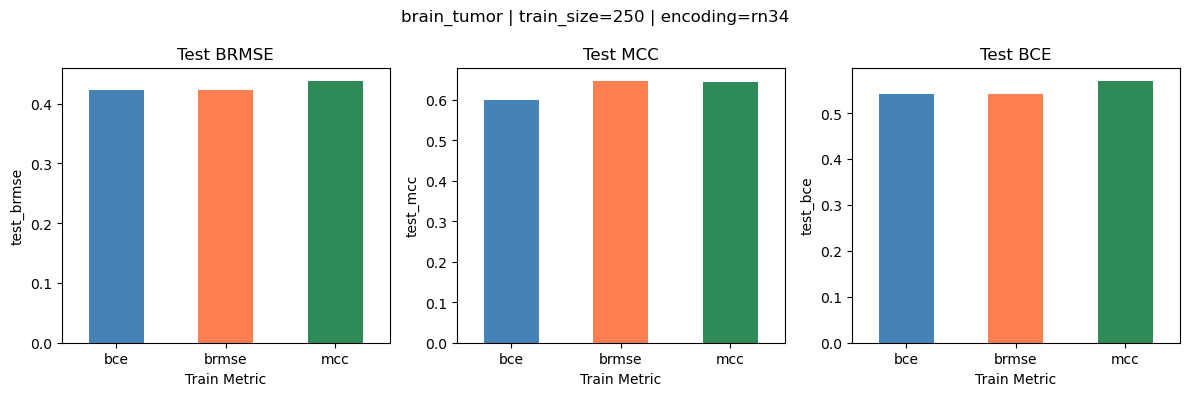

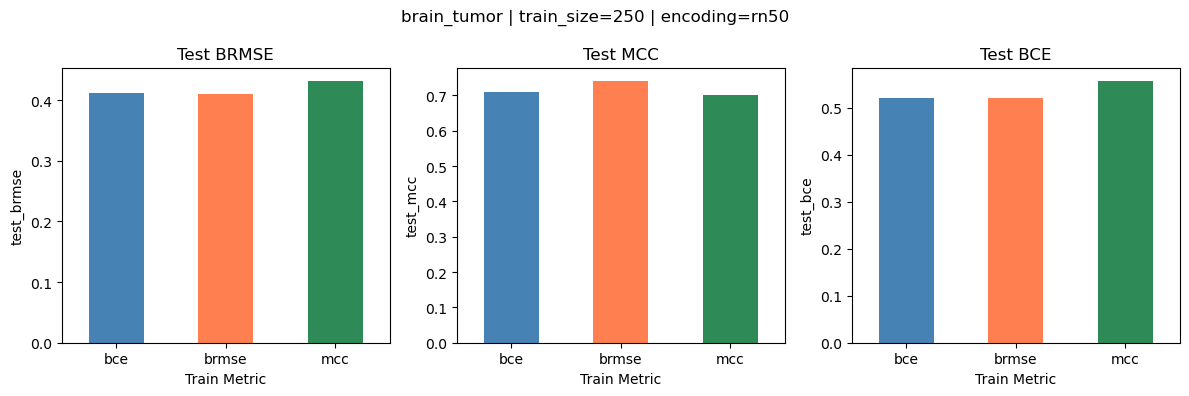

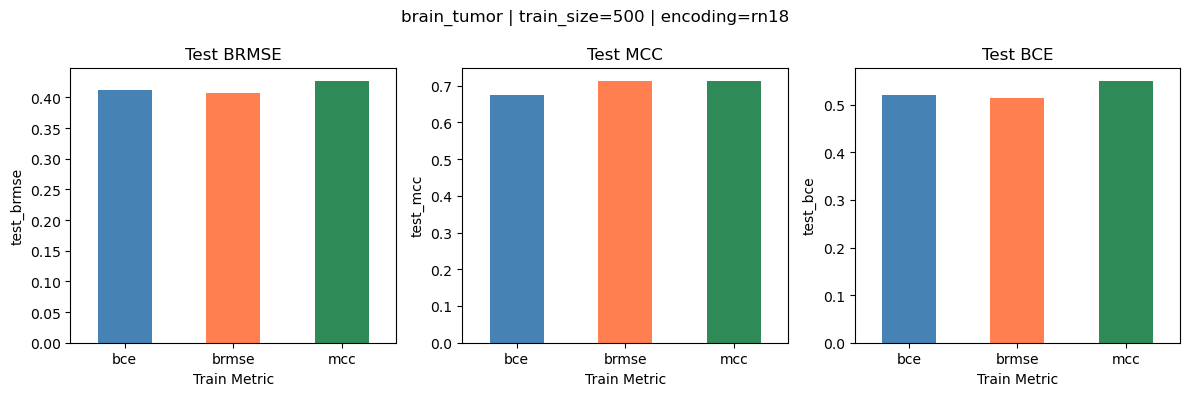

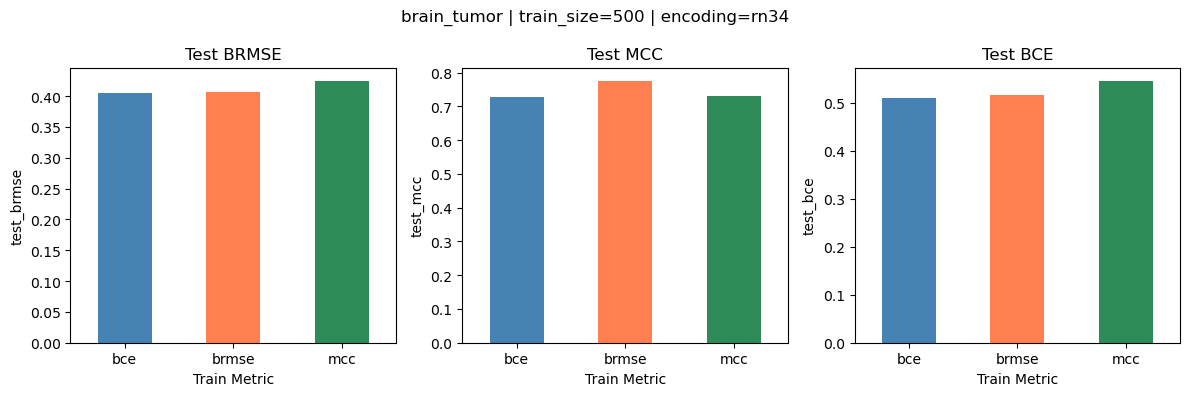

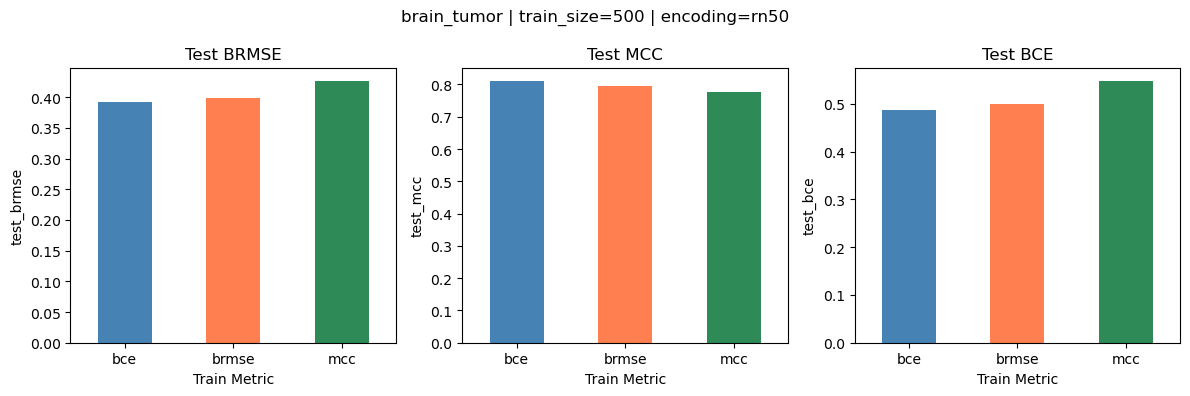

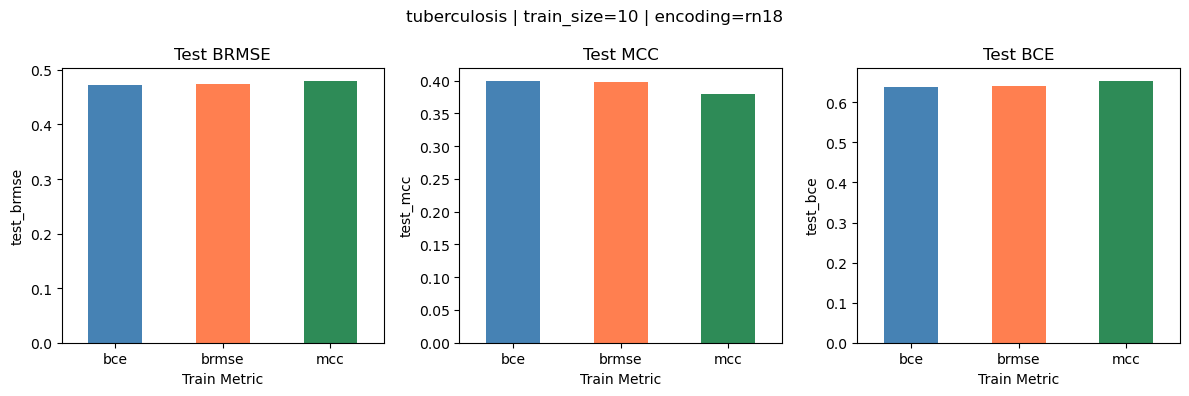

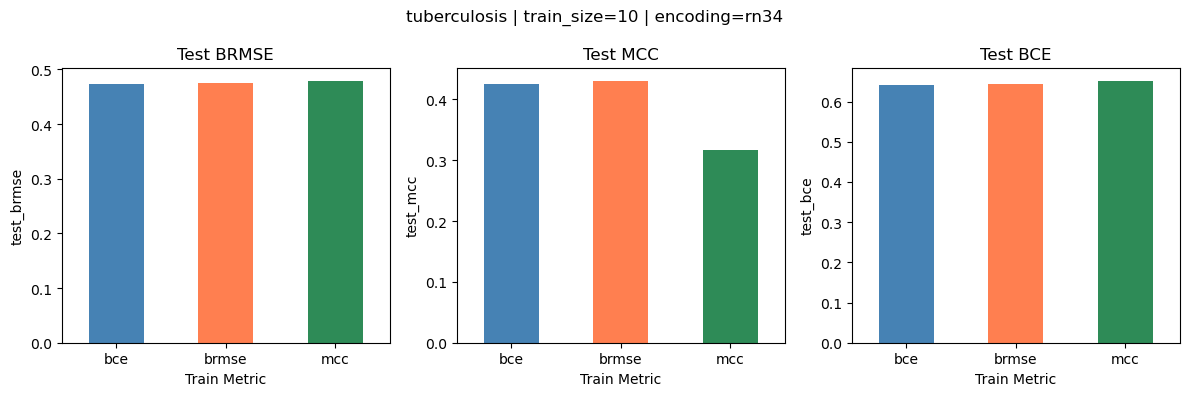

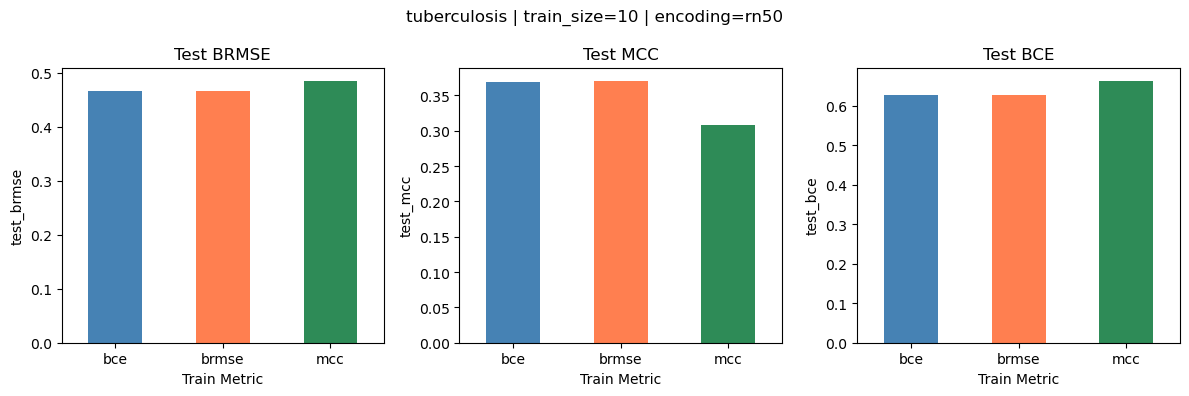

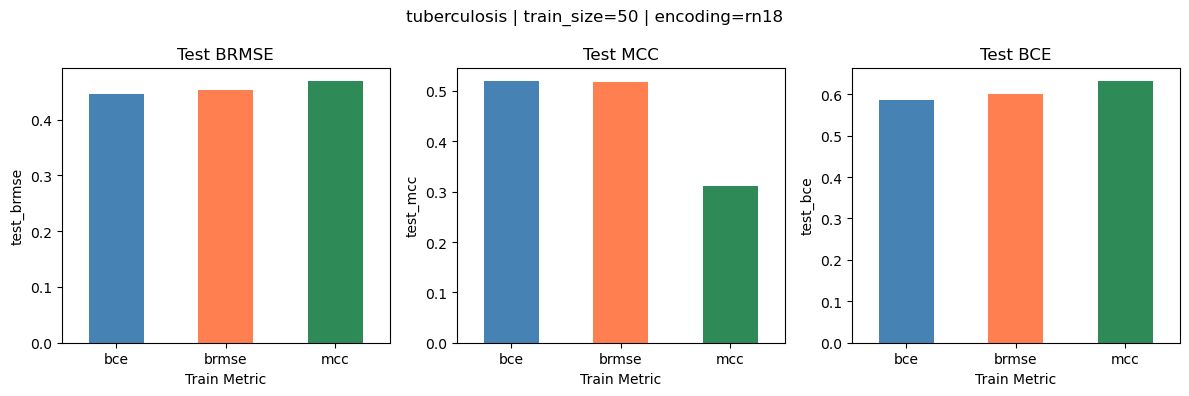

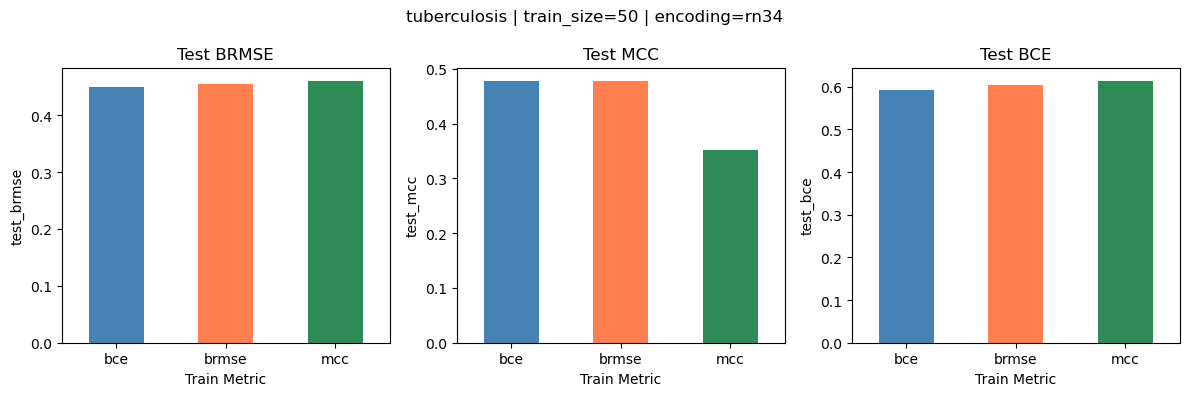

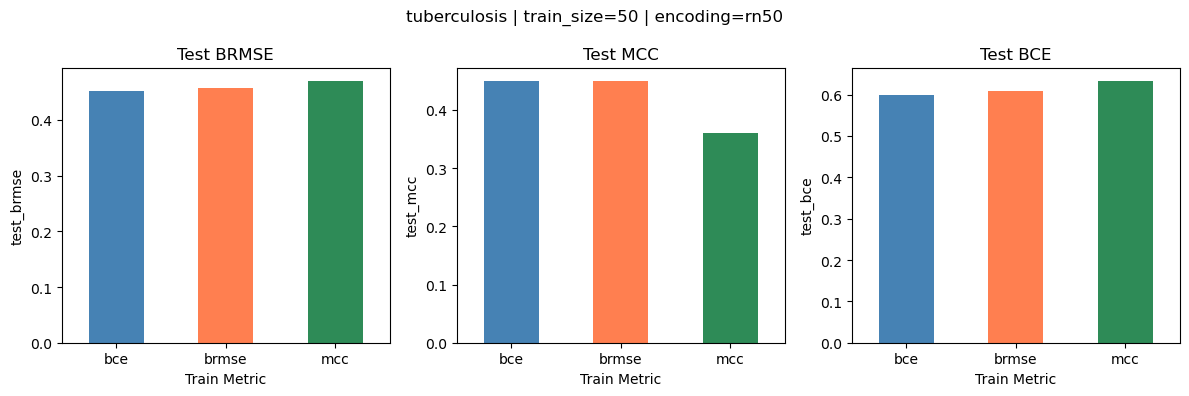

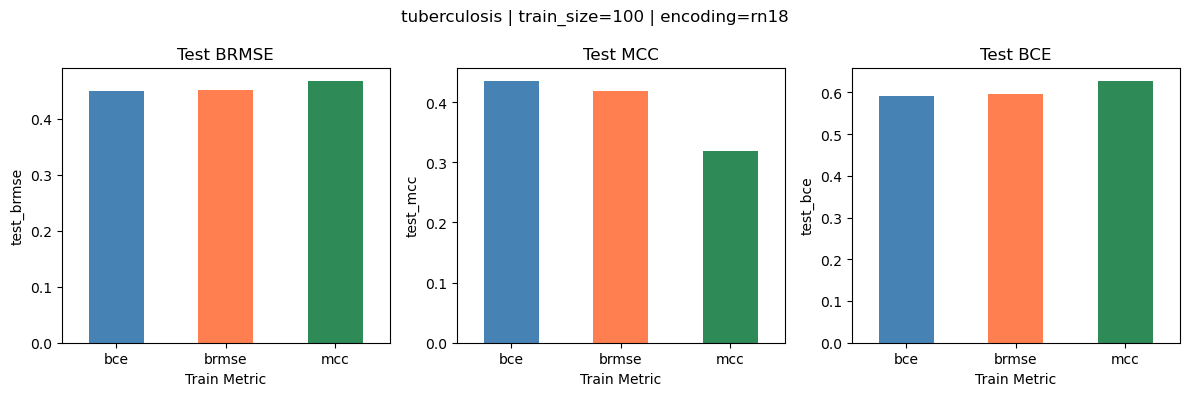

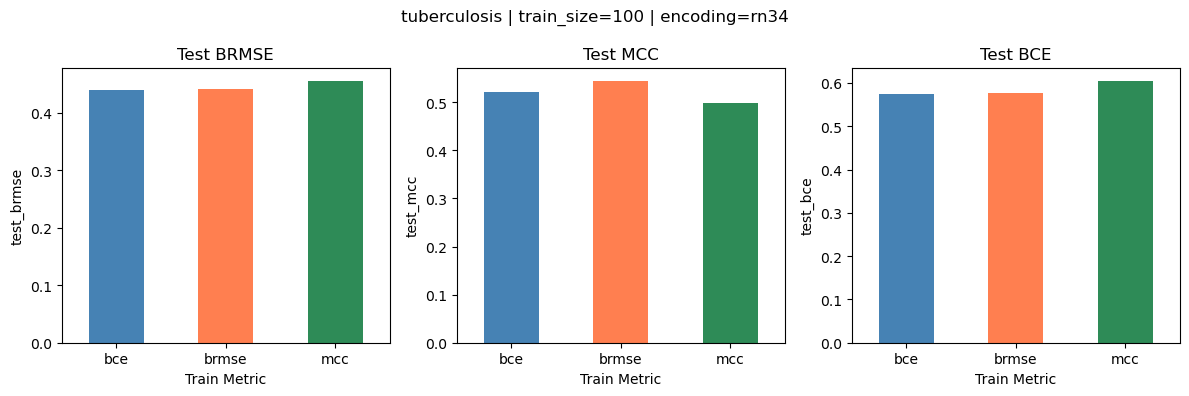

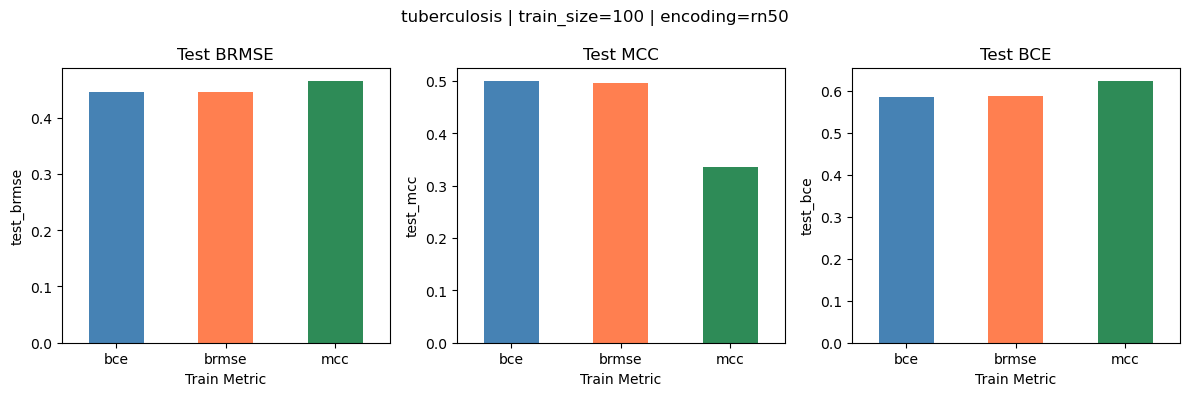

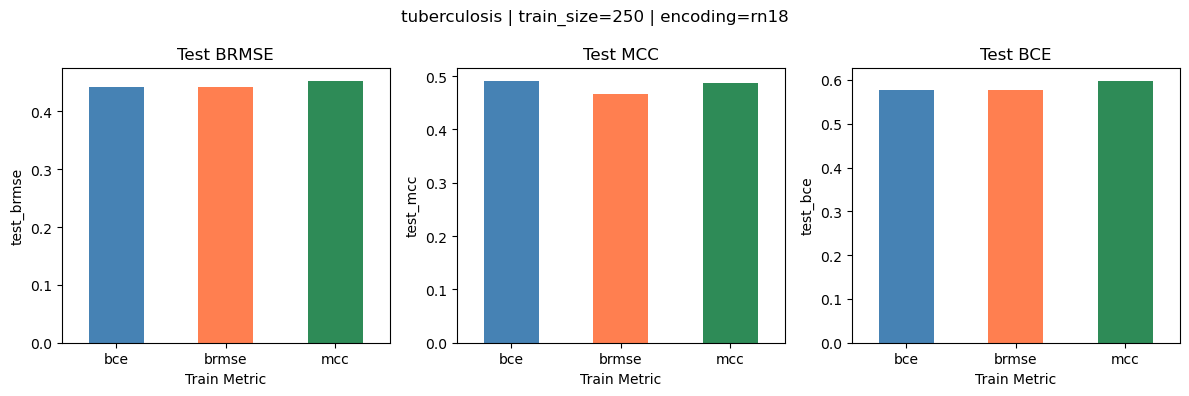

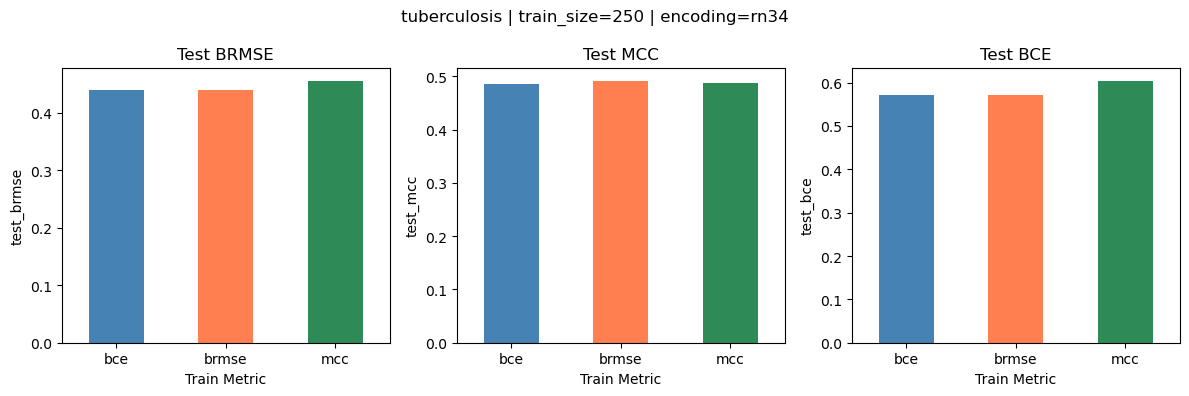

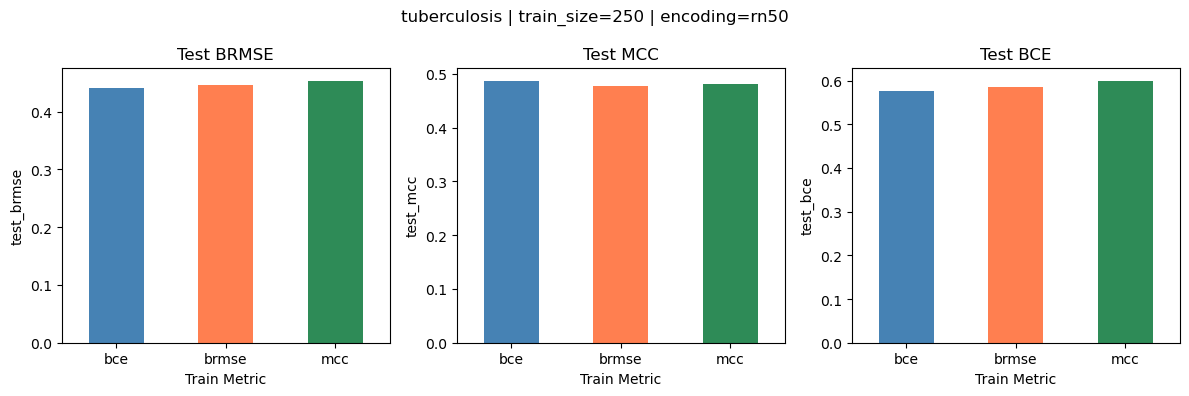

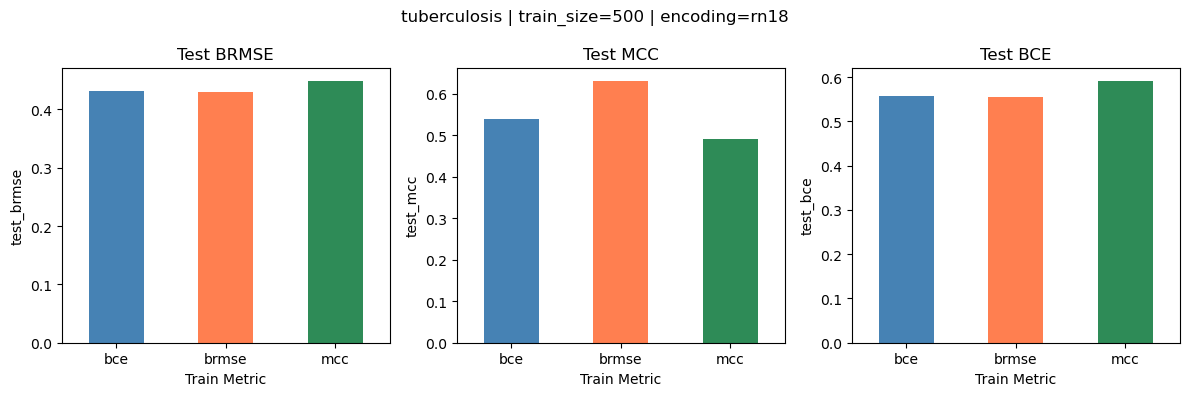

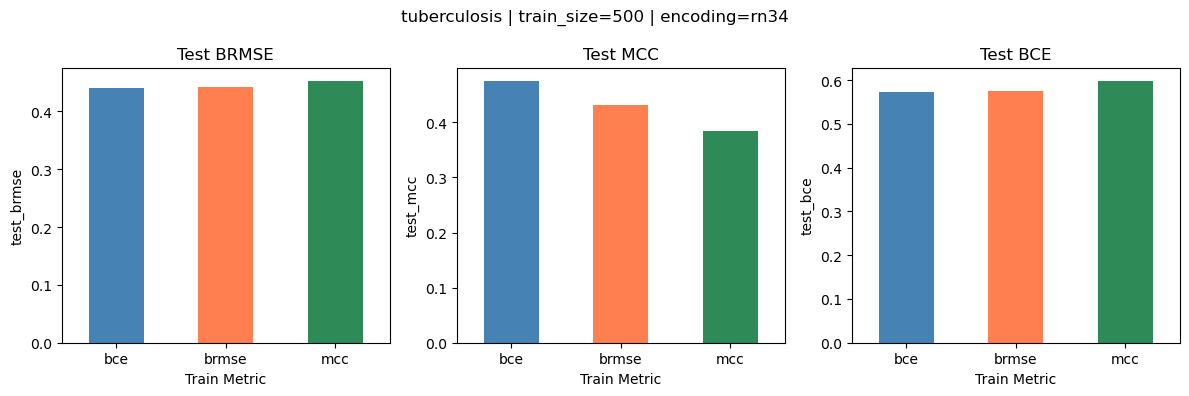

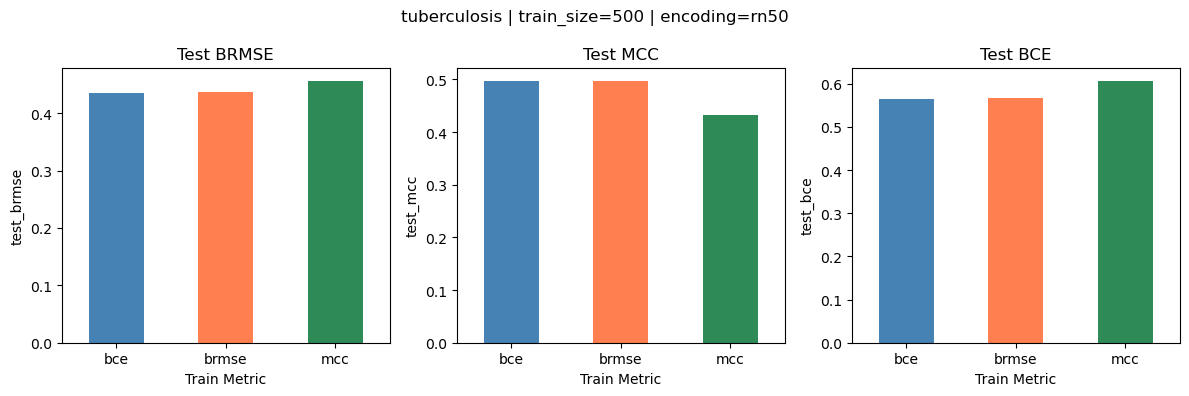

In [39]:
# Create plots for each dataset/train_size/encoding combination
for dataset in datasets:
    for train_size in train_sizes:
        for encoding in encodings:
            subset = df[(df['dataset'] == dataset) & 
                       (df['train_size'] == train_size) & 
                       (df['encoding'] == encoding)]
            
            if len(subset) == 0:
                continue
            
            metrics_comparison = subset.groupby('train_metric')[['test_brmse', 'test_mcc', 'test_bce']].median()
            
            if len(metrics_comparison) < 2:
                continue
            
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            fig.suptitle(f'{dataset} | train_size={train_size} | encoding={encoding}')
            
            test_metrics = ['test_brmse', 'test_mcc', 'test_bce']
            titles = ['Test BRMSE', 'Test MCC', 'Test BCE']
            
            for ax, metric, title in zip(axes, test_metrics, titles):
                metrics_comparison[metric].plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'seagreen'][:len(metrics_comparison)])
                ax.set_title(title)
                ax.set_xlabel('Train Metric')
                ax.set_ylabel(metric)
                ax.tick_params(axis='x', rotation=0)
            
            plt.tight_layout()
            plt.show()

In [53]:
test_metrics = ['test_brmse', 'test_mcc', 'test_bce']

def compute_rankings(group):
    """Compute rankings for each test metric (lower is better for brmse/bce, higher for mcc)"""
    rankings = {}
    for metric in test_metrics:
        if metric == 'test_mcc':
            # Higher is better for MCC
            rankings[metric] = group.groupby('train_metric')[metric].mean().rank(ascending=False)
        else:
            # Lower is better for BRMSE and BCE
            rankings[metric] = group.groupby('train_metric')[metric].mean().rank(ascending=True)
    return pd.DataFrame(rankings)

def plot_rankings(data_dict, title, filename):
    """Plot rankings as grouped bar chart"""
    n_groups = len(data_dict)
    if n_groups == 0:
        return
    
    fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 4), squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    colors = ['steelblue', 'coral', 'seagreen', 'purple', 'orange']
    
    for idx, (name, ranks_df) in enumerate(data_dict.items()):
        ax = axes[0, idx]
        
        x = np.arange(len(test_metrics))
        width = 0.8 / len(ranks_df)
        
        for i, (train_metric, row) in enumerate(ranks_df.iterrows()):
            offset = (i - len(ranks_df)/2 + 0.5) * width
            bars = ax.bar(x + offset, row[test_metrics], width, label=train_metric, color=colors[i % len(colors)])
        
        ax.set_xlabel('Test Metric')
        ax.set_ylabel('Median Rank (lower is better)')
        ax.set_title(name)
        ax.set_xticks(x)
        ax.set_xticklabels(['BRMSE', 'MCC', 'BCE'])
        ax.legend(title='Train Metric')
        ax.set_ylim(0, ranks_df.values.max() + 0.5)
    
    plt.tight_layout()
    # plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    # print(f"Saved: {filename}")

MEDIAN RANKINGS BY DATASET


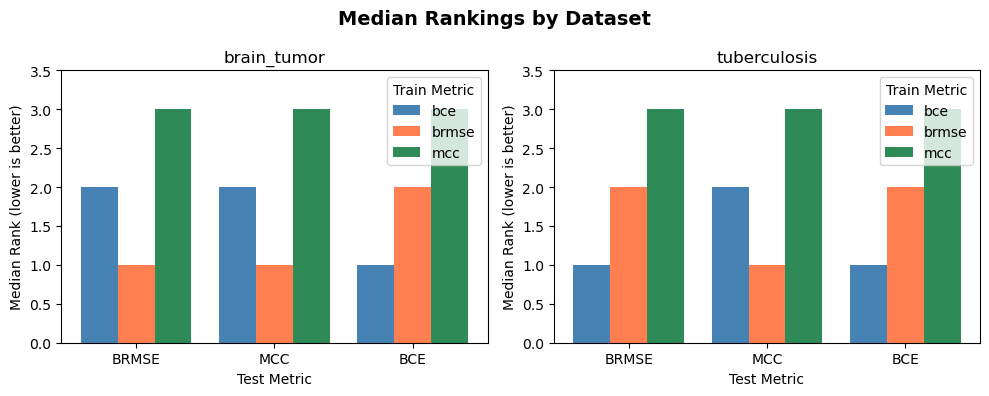

In [61]:
# 1. Rankings by dataset
print("=" * 70)
print("MEDIAN RANKINGS BY DATASET")
print("=" * 70)

dataset_rankings = {}
for dataset in df['dataset'].unique():
    subset = df[df['dataset'] == dataset]
    
    all_rankings = []
    for train_size in subset['train_size'].unique():
        for encoding in subset['encoding'].unique():
            sub = subset[(subset['train_size'] == train_size) & (subset['encoding'] == encoding)  & (subset['generation'] == 1000)]
            if len(sub) > 0 and sub['train_metric'].nunique() > 1:
                ranks = compute_rankings(sub)
                all_rankings.append(ranks)
    
    if all_rankings:
        combined = pd.concat(all_rankings)
        median_ranks = combined.groupby(combined.index).median()
        dataset_rankings[dataset] = median_ranks

plot_rankings(dataset_rankings, "Median Rankings by Dataset", "rankings_by_dataset.png")


MEDIAN RANKINGS BY DATASET + TRAIN SIZE


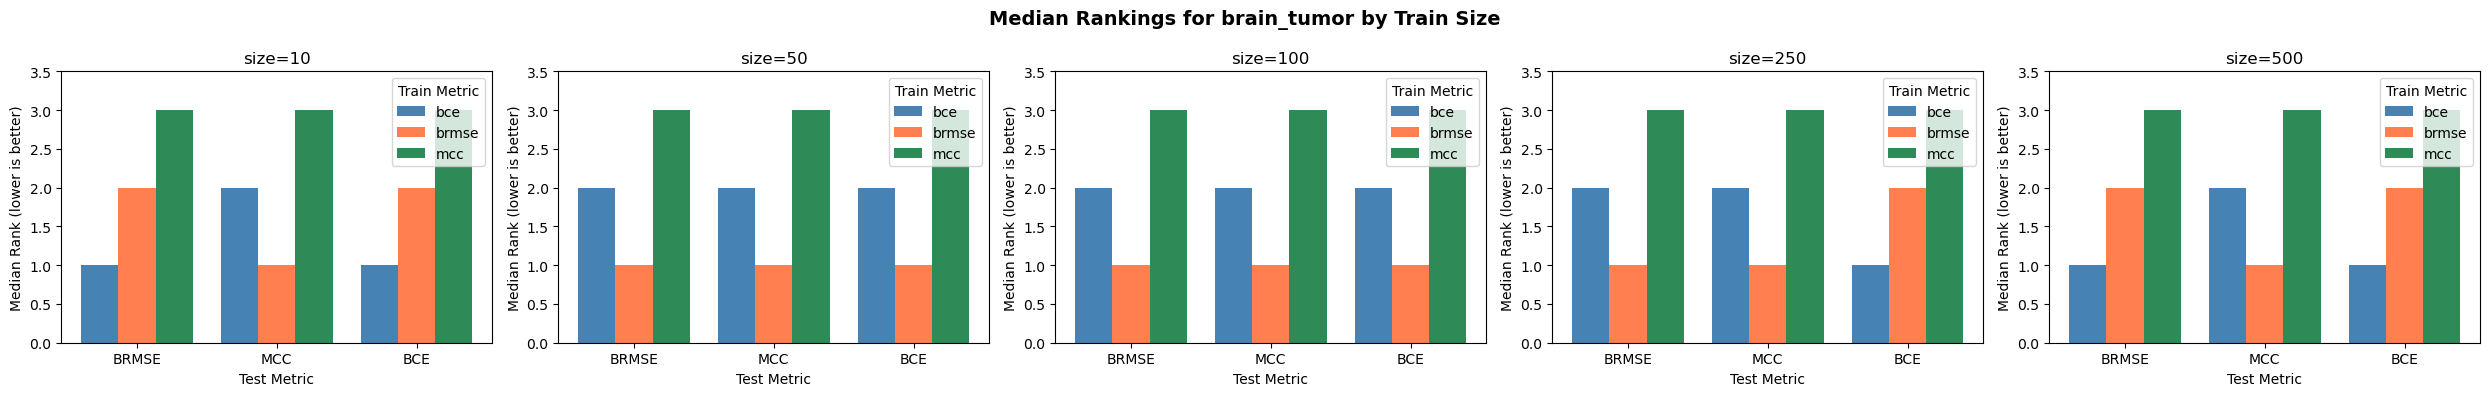

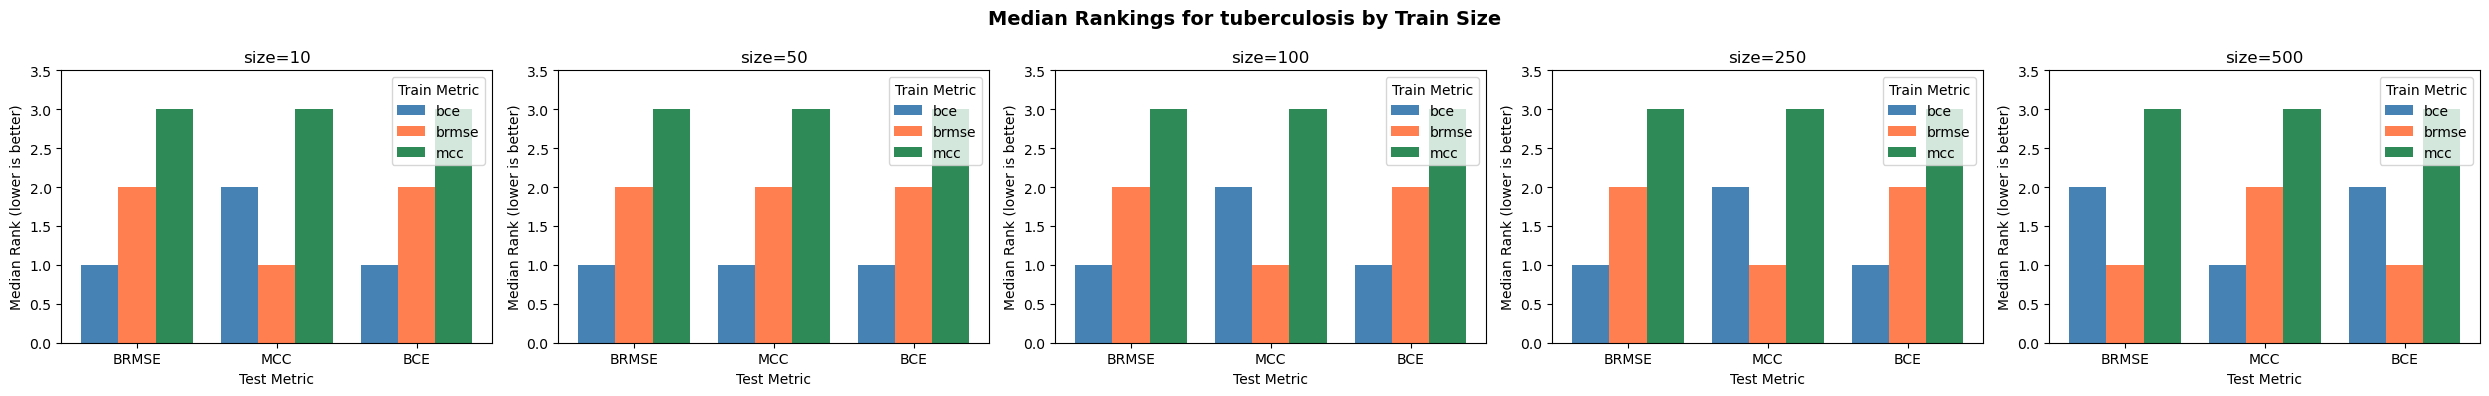

In [65]:
# 2. Rankings by dataset + train_size
print("\n" + "=" * 70)
print("MEDIAN RANKINGS BY DATASET + TRAIN SIZE")
print("=" * 70)

for dataset in df['dataset'].unique():
    size_rankings = {}
    
    for train_size in df['train_size'].unique():
        subset = df[(df['dataset'] == dataset) & (df['train_size'] == train_size) & (df['generation'] == 1000)]
        
        if len(subset) == 0 or subset['train_metric'].nunique() < 2:
            continue
        
        all_rankings = []
        for encoding in subset['encoding'].unique():
            sub = subset[subset['encoding'] == encoding]
            if len(sub) > 0 and sub['train_metric'].nunique() > 1:
                ranks = compute_rankings(sub)
                all_rankings.append(ranks)
        
        if all_rankings:
            combined = pd.concat(all_rankings)
            median_ranks = combined.groupby(combined.index).median()
            size_rankings[f"size={train_size}"] = median_ranks
    
    if size_rankings:
        plot_rankings(size_rankings, f"Median Rankings for {dataset} by Train Size", f"rankings_{dataset}_by_size.png")



MEDIAN RANKINGS BY DATASET + ENCODING


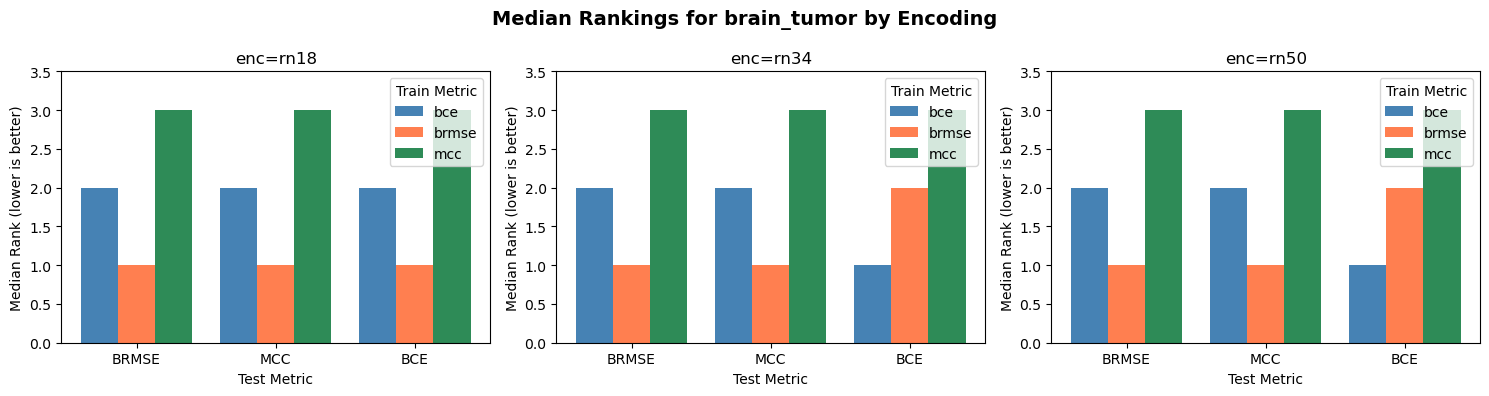

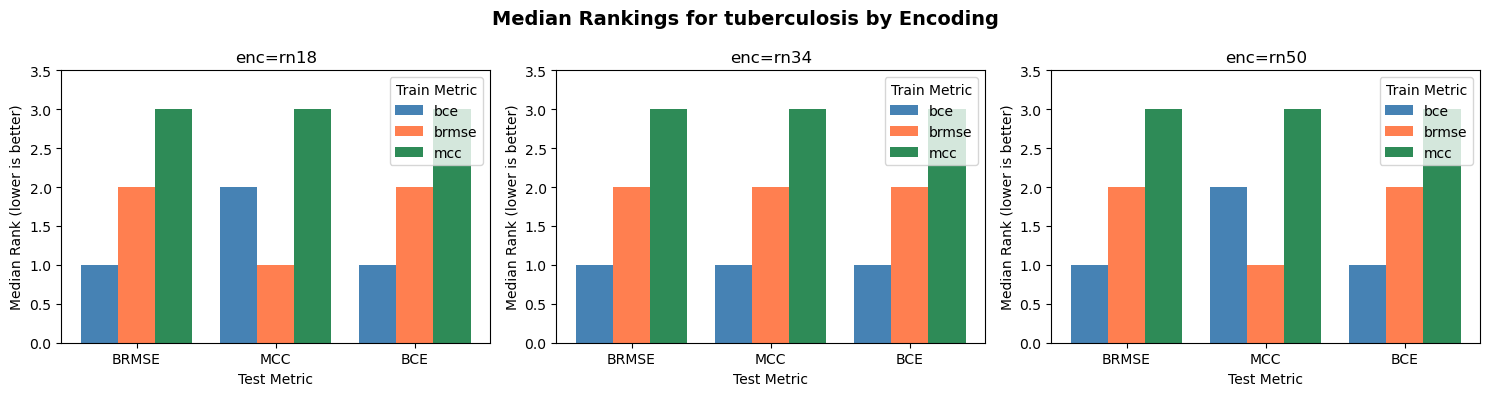

In [66]:
# 3. Rankings by dataset + encoding
print("\n" + "=" * 70)
print("MEDIAN RANKINGS BY DATASET + ENCODING")
print("=" * 70)

for dataset in df['dataset'].unique():
    encoding_rankings = {}
    
    for encoding in df['encoding'].unique():
        subset = df[(df['dataset'] == dataset) & (df['encoding'] == encoding) & (df['generation'] == 1000)]
        
        if len(subset) == 0 or subset['train_metric'].nunique() < 2:
            continue
        
        all_rankings = []
        for train_size in subset['train_size'].unique():
            sub = subset[subset['train_size'] == train_size]
            if len(sub) > 0 and sub['train_metric'].nunique() > 1:
                ranks = compute_rankings(sub)
                all_rankings.append(ranks)
        
        if all_rankings:
            combined = pd.concat(all_rankings)
            median_ranks = combined.groupby(combined.index).median()
            encoding_rankings[f"enc={encoding}"] = median_ranks
    
    if encoding_rankings:
        plot_rankings(encoding_rankings, f"Median Rankings for {dataset} by Encoding", f"rankings_{dataset}_by_encoding.png")

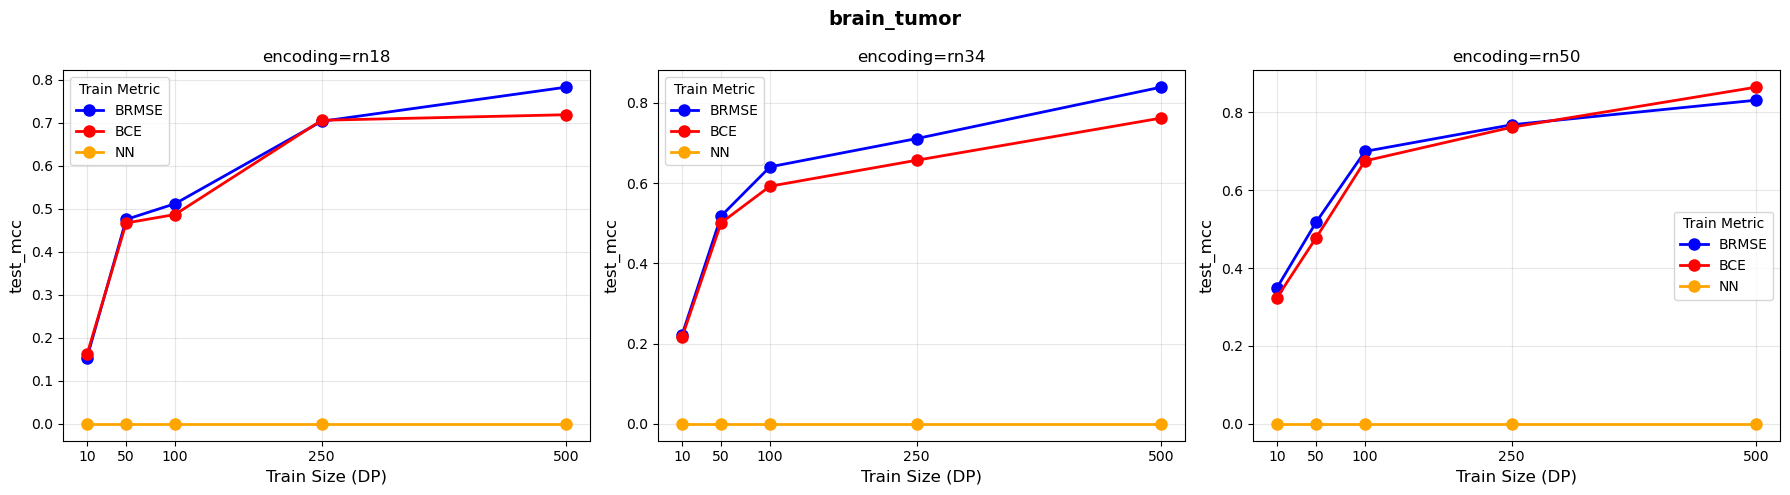

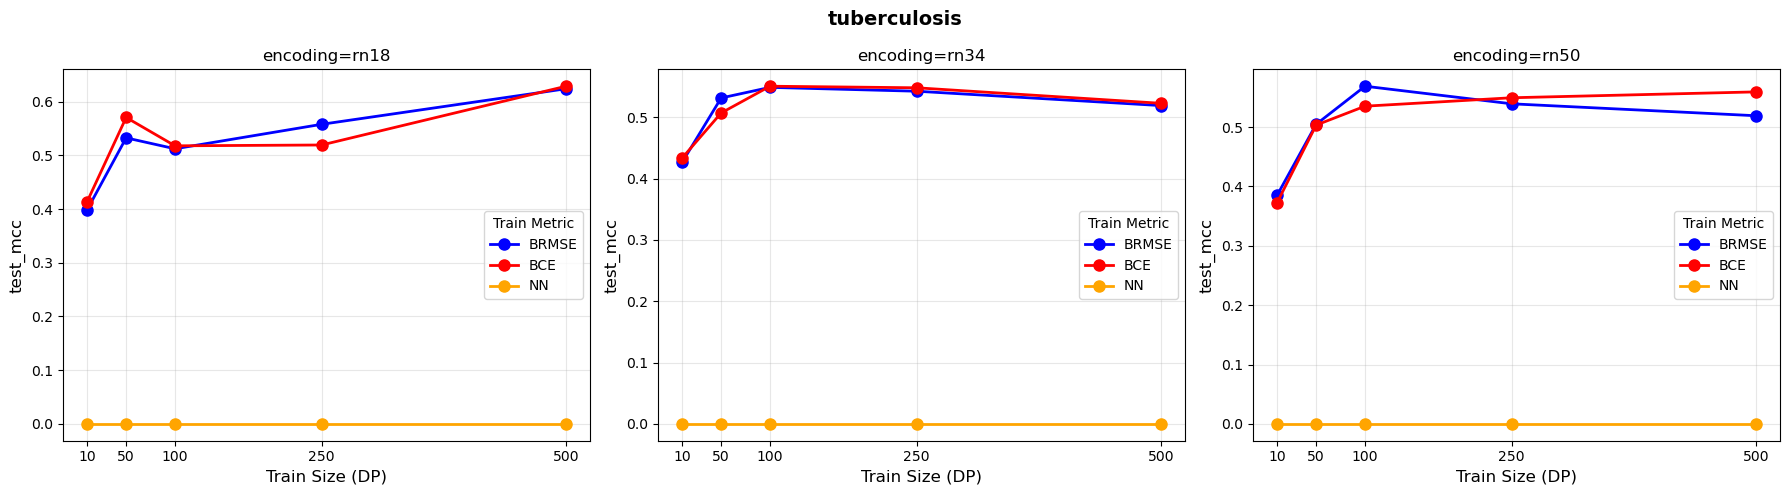

In [48]:
# Keep only last generation for each run
# df = df.merge(last_gen, on=['dataset', 'encoding', 'train_size', 'train_metric', 'seed', 'generation'])

# Parameter to choose metric
METRIC = 'test_mcc'  # Change this to: 'test_brmse', 'test_mcc', or 'test_bce'

# Colors for train_metric
colors = {'brmse': 'blue', 'bce': 'red'}

# Get unique datasets and encodings
datasets = df['dataset'].unique()
encodings = df['encoding'].unique()

for dataset in datasets:
    n_encodings = len([e for e in encodings if len(df[(df['dataset'] == dataset) & (df['encoding'] == e)]) > 0])
    
    if n_encodings == 0:
        continue
    
    fig, axes = plt.subplots(1, n_encodings, figsize=(6 * n_encodings, 5), squeeze=False)
    fig.suptitle(f'{dataset}', fontsize=14, fontweight='bold')
    
    plot_idx = 0
    for encoding in encodings:
        subset = df[(df['dataset'] == dataset) & (df['encoding'] == encoding) & (df['generation'] == 1000)]

        
        
        if len(subset) == 0:
            continue
        
        ax = axes[0, plot_idx]
        
        for train_metric in ['brmse', 'bce']:
            data = subset[subset['train_metric'] == train_metric]
            
            if len(data) == 0:
                continue
            
            # Group by train_size and compute mean
            grouped = data.groupby('train_size')[METRIC].median().sort_index()
            
            color = colors.get(train_metric, 'gray')
            ax.plot(grouped.index, grouped.values, 'o-', color=color, label=train_metric.upper(), linewidth=2, markersize=8)

        subset_nn = baseline_nn[(baseline_nn['dataset'] == dataset) & (baseline_nn['encoding'] == encoding) ]
        
        grouped_nn = subset_nn.groupby('train_size')[METRIC].median().sort_index()
        ax.plot(grouped_nn.index, grouped_nn.values, 'o-', color='orange', label='NN', linewidth=2, markersize=8)
        
        ax.set_xlabel('Train Size', fontsize=12)
        ax.set_ylabel(METRIC, fontsize=12)
        ax.set_title(f'encoding={encoding}', fontsize=12)
        ax.legend(title='Train Metric')
        ax.set_xticks(sorted(subset['train_size'].unique()))
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    plt.tight_layout()
    # filename = f'perf_{dataset}_{METRIC}.png'
    # plt.savefig(filename, dpi=150)
    plt.show()
    # print(f"Saved: {filename}")